# Mobile Phone Price Prediction using Machine Learning

This project focuses on predicting the prices of mobile phones using 3 machine learning regression models. The models implemented include **Linear Regression, Random Forest Regressor, XGBoost Regressor**.

The objective is to analyze and compare the performance of these models to determine which one most accurately predicts mobile phone prices based on key features such as **RAM, storage, battery capacity, brand, camera specifications, and mobile weight**.

By leveraging these models, this research provides valuable insights into **pricing trends in the mobile phone market** and can assist **consumers, retailers, and manufacturers** in making informed, data-driven decisions regarding product pricing and positioning.


## Step 1: Importing Required Libraries and Models


In [41]:
# ============================
# Import Required Libraries
# ============================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Preprocessing & Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

# Tabular Results
from tabulate import tabulate

# MLflow for Experiment Tracking
import mlflow

# Model Persistence
import joblib
import os

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Set MLflow tracking URI (creates local mlruns directory)
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("Mobile_Price_Prediction")


2025/11/26 11:03:04 INFO mlflow.tracking.fluent: Experiment with name 'Mobile_Price_Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:///Users/boren/Desktop/E2E ML '
 'Pipeline/training/notebooks/../mlruns/265847738299252557'), creation_time=1764129784431, experiment_id='265847738299252557', last_update_time=1764129784431, lifecycle_stage='active', name='Mobile_Price_Prediction', tags={}>

## Step 2: Data Collection 

In [42]:
data = pd.read_csv('../data/Mobiles Dataset (2025).csv', encoding='latin1')

In [43]:
data = data[['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera', 'Battery Capacity', 'Screen Size', 'Launched Price (Pakistan)']]
data.shape

(930, 9)

## Step 3: Data Preprocessing

In [44]:
# Check for null value
data.isnull().sum()

Company Name                 0
Model Name                   0
Mobile Weight                0
RAM                          0
Front Camera                 0
Back Camera                  0
Battery Capacity             0
Screen Size                  0
Launched Price (Pakistan)    0
dtype: int64

In [45]:
# Helper function to clean numeric columns
def clean_numeric(series, remove_str="", round_to_int=False):
    cleaned = (
        series.astype(str)
        .str.replace(remove_str, "", regex=False)
        .str.replace("Not available", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.extract(r"(\d+\.?\d*)")[0]   # extract numbers + decimals
    )
    # Convert to numeric safely (NaN if invalid)
    cleaned = pd.to_numeric(cleaned, errors="coerce")
    
    if round_to_int:
        cleaned = cleaned.round().astype("Int64")  # nullable int (avoids crash on NaN)
    
    return cleaned


PKR_TO_USD_RATE = 278.0  # approx conversion rate PKR→USD

# --- Cleaning process ---
print("Columns:", data.columns.tolist())

# Mobile Weight
if "Mobile Weight" in data.columns:
    data["Mobile Weight"] = clean_numeric(data["Mobile Weight"], remove_str="g")

# RAM
if "RAM" in data.columns:
    data["RAM"] = clean_numeric(data["RAM"], remove_str="GB", round_to_int=True)

# Front Camera
if "Front Camera" in data.columns:
    data["Front Camera"] = clean_numeric(data["Front Camera"], remove_str="MP")

# Back Camera
if "Back Camera" in data.columns:
    data["Back Camera"] = clean_numeric(data["Back Camera"], remove_str="MP")

# Rear / Primary Camera (handle whichever exists)
for cam_col in ["Primary Camera", "Rear Camera", "Main Camera"]:
    if cam_col in data.columns:
        data[cam_col] = clean_numeric(data[cam_col], remove_str="MP")

# Battery
if "Battery Capacity" in data.columns:
    data["Battery Capacity"] = clean_numeric(data["Battery Capacity"], remove_str="mAh", round_to_int=True)

# Internal Storage
if "Internal Storage" in data.columns:
    data["Internal Storage"] = clean_numeric(data["Internal Storage"], remove_str="GB", round_to_int=True)

# Screen Size
if "Screen Size" in data.columns:
    data["Screen Size"] = clean_numeric(data["Screen Size"], remove_str="inches")

# Launched Price
PRICE_COL_PK = "Launched Price (Pakistan)"
PRICE_COL_USD = "Price"
if PRICE_COL_PK in data.columns:
    data[PRICE_COL_PK] = (
        data[PRICE_COL_PK]
        .astype(str)
        .str.replace("PKR", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("Not available", "", regex=False)
        .str.extract(r"(\d+\.?\d*)")[0]
    )
    data[PRICE_COL_PK] = pd.to_numeric(data[PRICE_COL_PK], errors="coerce")
    data[PRICE_COL_PK] = data[PRICE_COL_PK] / PKR_TO_USD_RATE
    data.rename(columns={PRICE_COL_PK: PRICE_COL_USD}, inplace=True)


Columns: ['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera', 'Battery Capacity', 'Screen Size', 'Launched Price (Pakistan)']


In [46]:
data.head()

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Battery Capacity,Screen Size,Price
0,Apple,iPhone 16 128GB,174.0,6,12.0,48.0,3600,6.1,809.348921
1,Apple,iPhone 16 256GB,174.0,6,12.0,48.0,3600,6.1,845.320144
2,Apple,iPhone 16 512GB,174.0,6,12.0,48.0,3600,6.1,881.291367
3,Apple,iPhone 16 Plus 128GB,203.0,6,12.0,48.0,4200,6.7,899.276978
4,Apple,iPhone 16 Plus 256GB,203.0,6,12.0,48.0,4200,6.7,935.248201


In [47]:
# Remove the duplicate values
data.drop_duplicates(inplace=True)
data.shape

(915, 9)

## Step 4: Initial Data Exploration & Visualization

In [48]:
data.describe()

,Mobile Weight,RAM,Front Camera,Back Camera,Battery Capacity,Screen Size,Price
count,915.000000,915.0,915.000000,915.000000,915.0,915.000000,914.000000
mean,228.914098,7.790164,18.166776,46.491585,5030.280874,7.092678,455.248957
std,106.164933,3.189444,12.043474,31.124175,1365.571834,1.544578,367.012968
min,135.000000,1.0,2.000000,5.000000,2000.0,5.000000,57.550360
25%,185.000000,6.0,8.000000,13.000000,4400.0,6.500000,197.838129
50%,195.000000,8.0,16.000000,50.000000,5000.0,6.670000,323.737410
75%,209.000000,8.0,32.000000,50.000000,5100.0,6.780000,647.478417
max,732.000000,16.0,60.000000,200.000000,11200.0,14.600000,2176.255396


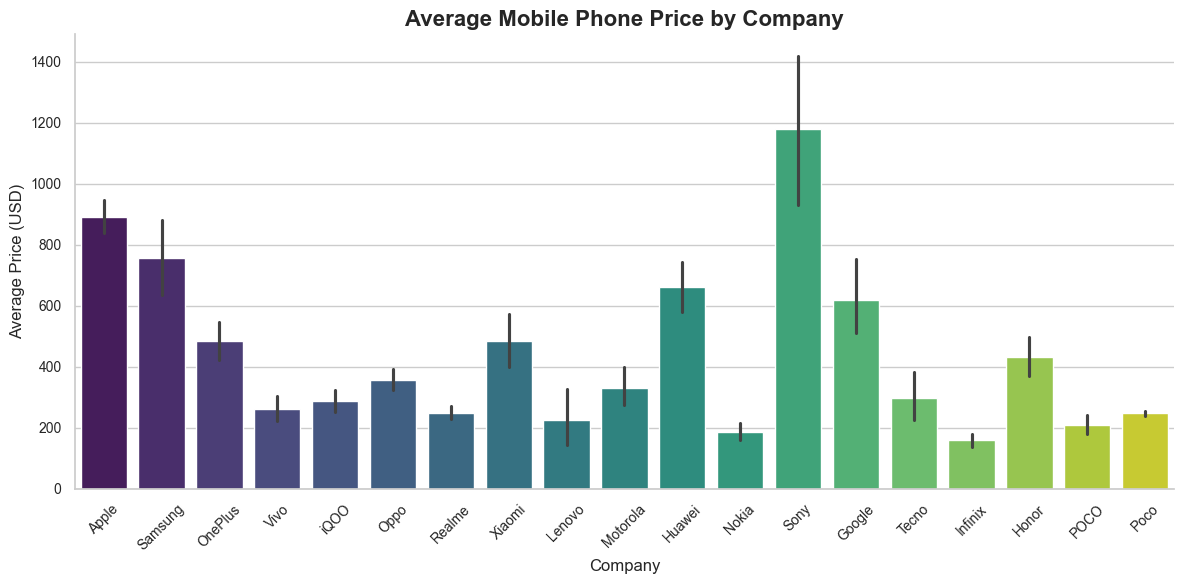

In [49]:
plt.figure(figsize=(12,6))
sns.barplot(
    x="Company Name", 
    y="Price", 
    data=data, 
    estimator=np.mean, 
    palette="viridis"
)

plt.title("Average Mobile Phone Price by Company", fontsize=16, fontweight='bold')
plt.xlabel("Company", fontsize=12)
plt.ylabel("Average Price (USD)", fontsize=12)

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

sns.despine()  # removes top and right border for cleaner look
plt.tight_layout()
plt.show()


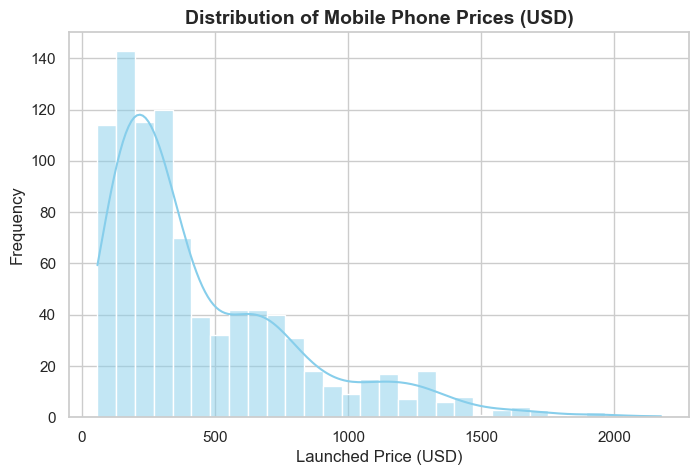

In [50]:
plt.figure(figsize=(8,5))
sns.histplot(data['Price'], bins=30, kde=True, color="skyblue")
plt.xlabel("Launched Price (USD)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Mobile Phone Prices (USD)", fontsize=14, fontweight="bold")
plt.show()


`This histogram shows the distribution of mobile phone launch prices in Pakistan. The x-axis 
represents different price ranges in PKR (Pakistani Rupees), while the y-axis shows how many 
mobile phones fall within each price range.`

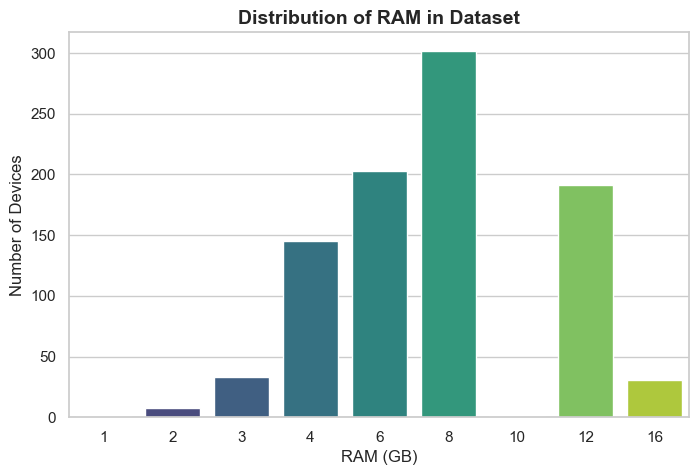

In [51]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,5))
sns.countplot(x='RAM', data=data, palette="viridis", order=sorted(data['RAM'].unique()))
plt.title('Distribution of RAM in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('RAM (GB)')
plt.ylabel('Number of Devices')
plt.show()


`This countplot visualizes the number of mobile phones with different RAM capacities in dataset. 
It helps us understand which RAM options are most common in mobile phones.`

### What is Correlation?
`Correlation values range from -1 to 1:`

`+1: Perfect positive correlation – when one increases, the other increases.`

`-1: Perfect negative correlation – when one increases, the other decreases.`

`0: No linear relationship.`

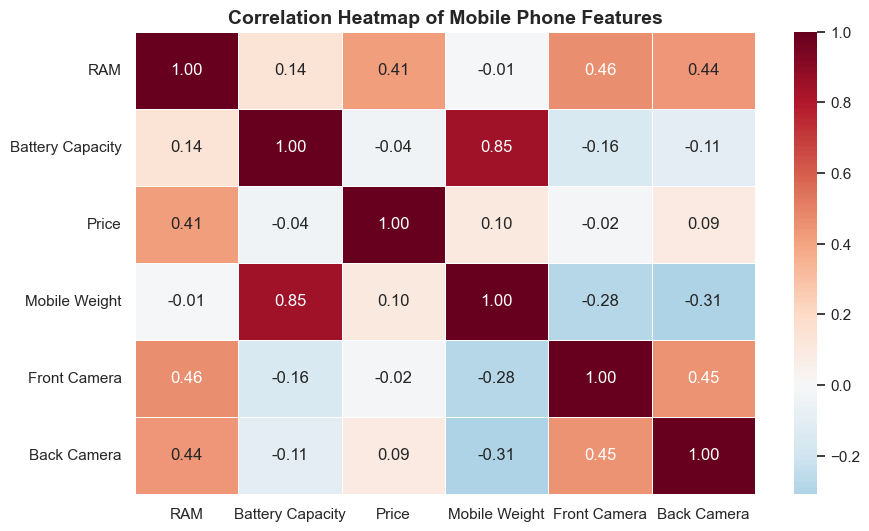

In [52]:
# Select only numerical columns
numeric_data = data[['RAM', 'Battery Capacity', 'Price', 
                     'Mobile Weight', 'Front Camera', 'Back Camera']]

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Mobile Phone Features", fontsize=14, fontweight="bold")
plt.show()


`This heatmap shows how strongly different features are related. For example, we see that phones with higher battery capacity are usually heavier (0.85), and more RAM often comes with better front cameras (0.47). However, price is not strongly tied to any single feature, meaning it likely depends on a combination of factors.`

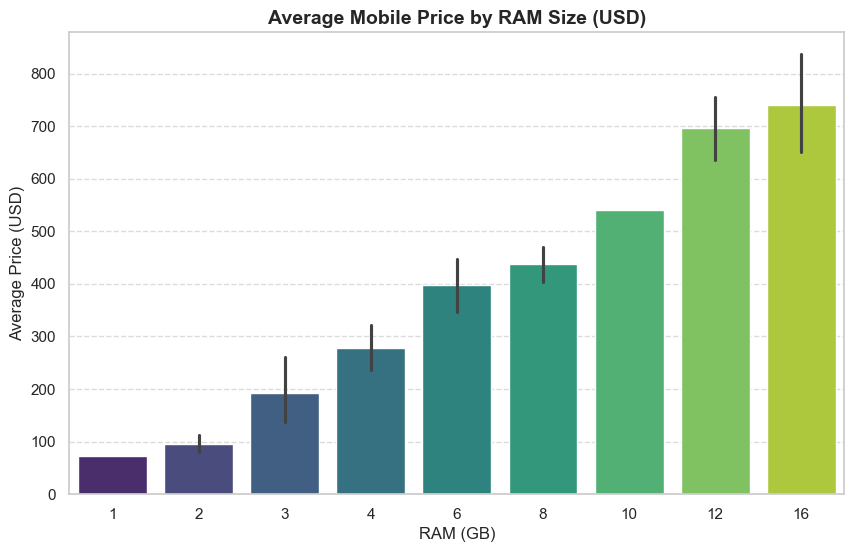

In [53]:
plt.figure(figsize=(10,6))
sns.barplot(
    x="RAM", 
    y="Price", 
    data=data, 
    estimator=np.mean, 
    palette="viridis"
)

# Titles and labels
plt.title("Average Mobile Price by RAM Size (USD)", fontsize=14, fontweight="bold")
plt.xlabel("RAM (GB)", fontsize=12)
plt.ylabel("Average Price (USD)", fontsize=12)

# Rotate x-axis labels if needed
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)

# Add gridlines for readability
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


`The bar plot of Average Price by RAM helps us understand the relationship between RAM size and mobile phone prices in Pakistan. It highlights how pricing trends vary across different RAM capacities, allowing us to see whether higher RAM models generally correspond to higher average prices. This visualization makes it easier to interpret feature importance and market positioning compared to raw numbers alone`

## Step 5: Train-Test Split

In [54]:
# Drop rows where target variable is NaN
data = data.dropna(subset=['Price'])

X = data.drop(['Price', 'Company Name', 'Model Name'], axis=1)
y = data['Price']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
print(X.shape, X_train.shape, X_train.shape)

(914, 6) (731, 6) (731, 6)


## Step 7: Standardize Data for Linear Regression

In [57]:
# Standardized the data 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 8: Models Training and Evoluation

### i- Linear Regression Need Scaled Data
`Model like **Linear Regression** works by calculating distances or optimizing based on feature values. If one feature has very large values (e.g., salary) and another has small values (e.g., age), the large feature can dominate the model. So, we use **StandardScaler** to bring all features to the same scale.`
- `Use scaling for models that calculate distance or use gradients.`  

In [59]:
# Train Linear Regression with MLflow tracking
with mlflow.start_run(run_name="Linear_Regression"):
    model = LinearRegression()
    
    # Log parameters
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("scaled", True)
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("random_state", 42)
    
    # Train model
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Log metrics
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2_score", r2)
    
    # Log model with input example for signature inference
    input_example = X_train_scaled[0:1]  # First row as example
    mlflow.sklearn.log_model(
        model, 
        name="model",
        input_example=input_example
    )
    
    print("Linear Regression:")
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2 Score:", round(r2 * 100, 2), '%')
    print('MAE: ', mae)
    print("=" * 30)
    
    # Store for later comparison
    linear_model = model
    linear_metrics = {"mse": mse, "rmse": rmse, "mae": mae, "r2": r2}


Linear Regression:
MSE: 91485.1705301532
RMSE: 302.4651558942835
R2 Score: 39.21 %
MAE:  216.00349686321343


### ii.  Models That Do NOT Need Scaling:
`But models like **Random Forest**, and **XGBoost** don’t care about the size of the numbers. They just split the data based on values (like "is price > 500?"). So, they don’t need scaling.`
- `No need for scaling for tree-based models.`

In [60]:
# Define models with tuned parameters
models_unscaled = {
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        max_depth=7,
        learning_rate=0.05,
        n_estimators=1000,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=42
    )
}

# Train & evaluate each model with MLflow tracking
best_model = None
best_r2 = -float('inf')
best_model_name = None
model_storage = {}

for name, model in models_unscaled.items():
    with mlflow.start_run(run_name=name.replace(" ", "_")):
        # Log parameters
        mlflow.log_param("model_type", name)
        mlflow.log_param("scaled", False)
        mlflow.log_param("test_size", 0.2)
        mlflow.log_param("random_state", 42)
        
        # Log hyperparameters
        if name == "Random Forest":
            mlflow.log_param("n_estimators", model.n_estimators)
            mlflow.log_param("max_depth", model.max_depth)
            mlflow.log_param("min_samples_split", model.min_samples_split)
            mlflow.log_param("min_samples_leaf", model.min_samples_leaf)
            mlflow.log_param("max_features", model.max_features)
        elif name == "XGBoost":
            mlflow.log_param("n_estimators", model.n_estimators)
            mlflow.log_param("max_depth", model.max_depth)
            mlflow.log_param("learning_rate", model.learning_rate)
            mlflow.log_param("subsample", model.subsample)
            mlflow.log_param("colsample_bytree", model.colsample_bytree)
        
        # Train model
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Regression metrics
        mse = mean_squared_error(y_test, y_pred)
        rmse = sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Log metrics
        mlflow.log_metric("mse", mse)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2_score", r2)

        # Log model with input example for signature inference
        input_example = X_train.iloc[0:1].values  # First row as example (numpy array)
        if name == "XGBoost":
            mlflow.xgboost.log_model(
                model,
                name="model",
                input_example=input_example
            )
        else:
            mlflow.sklearn.log_model(
                model,
                name="model",
                input_example=input_example
            )

        print(f"{name}:")
        print(f"  MSE: {mse:.2f}")
        print(f"  RMSE: {rmse:.2f}")
        print(f"  MAE: {mae:.2f}")
        print(f"  R2 Score: {r2 * 100:.2f} %")
        print("=" * 50)
        
        # Track best model
        if r2 > best_r2:
            best_r2 = r2
            best_model = model
            best_model_name = name
        
        # Store model and metrics
        model_storage[name] = {
            "model": model,
            "metrics": {"mse": mse, "rmse": rmse, "mae": mae, "r2": r2}
        }


Random Forest:
  MSE: 17765.30
  RMSE: 133.29
  MAE: 87.47
  R2 Score: 88.20 %
XGBoost:
  MSE: 11853.10
  RMSE: 108.87
  MAE: 69.62
  R2 Score: 92.12 %


## Models Performance 

In [61]:
## Step 9: Save Best Model

# Save the best model and scaler
model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

# Save best model
best_model_path = os.path.join(model_dir, "best_model.joblib")
joblib.dump(best_model, best_model_path)
print(f"Best model ({best_model_name}) saved to {best_model_path}")
print(f"Best R2 Score: {best_r2 * 100:.2f}%")

# Save scaler (needed for preprocessing if using scaled features)
scaler_path = os.path.join(model_dir, "scaler.joblib")
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

# Also save feature names for API
feature_names = list(X_train.columns)
feature_names_path = os.path.join(model_dir, "feature_names.joblib")
joblib.dump(feature_names, feature_names_path)
print(f"Feature names saved to {feature_names_path}")


Best model (XGBoost) saved to ../models/best_model.joblib
Best R2 Score: 92.12%
Scaler saved to ../models/scaler.joblib
Feature names saved to ../models/feature_names.joblib


In [62]:
# Store results in a list (using already trained models)
results = []

# Add Linear Regression results
results.append(["Linear Regression", 
                linear_metrics["rmse"], 
                linear_metrics["mae"], 
                linear_metrics["r2"] * 100])

# Add unscaled models results
for name, model_data in model_storage.items():
    metrics = model_data["metrics"]
    results.append([name, 
                    metrics["rmse"], 
                    metrics["mae"], 
                    metrics["r2"] * 100])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R2 Score (%)"])

# Sort by best R² score
results_df = results_df.sort_values(by="R2 Score (%)", ascending=False).reset_index(drop=True)

# Round values for readability
results_df["RMSE"] = results_df["RMSE"].round(2)
results_df["MAE"] = results_df["MAE"].round(2)
results_df["R2 Score (%)"] = results_df["R2 Score (%)"].round(2)

# Print as a clean professional table
print(tabulate(results_df, headers="keys", tablefmt="fancy_grid", showindex=False))


╒═══════════════════╤════════╤════════╤════════════════╕
│ Model             │   RMSE │    MAE │   R2 Score (%) │
╞═══════════════════╪════════╪════════╪════════════════╡
│ XGBoost           │ 108.87 │  69.62 │          92.12 │
├───────────────────┼────────┼────────┼────────────────┤
│ Random Forest     │ 133.29 │  87.47 │          88.2  │
├───────────────────┼────────┼────────┼────────────────┤
│ Linear Regression │ 302.47 │ 216    │          39.21 │
╘═══════════════════╧════════╧════════╧════════════════╛



### 📊 Model Performance Comparison

To evaluate different regression algorithms, we trained both **tree-based ensemble models** (Random Forest, XGBoost) and **scaled models** (Linear Regression, KNN). Performance was compared using **RMSE, MAE, and R² score**.

This combined results table provides a clear benchmark of how each model performs, making it easier to identify the most accurate and reliable model for predicting mobile phone prices.



## Conclusion

This study evaluated 3 regression models for predicting mobile prices, highlighting notable differences in predictive performance.

* **Linear Regression** demonstrated limited predictive capability, with R² ≈ 39.2%, RMSE ≈ 84,085, and MAE ≈ 60,049.
* **Random Forest** significantly enhanced performance, attaining R² ≈ 88%.
* **XGBoost** achieved the highest accuracy (R² ≈ 92%) and the lowest error metrics, establishing it as the most effective model for this dataset.

Overall, ensemble tree-based methods outperformed simpler models, demonstrating the value of advanced algorithms for mobile price prediction. Future work may focus on feature engineering, hyperparameter optimization, and model stacking to further improve predictive accuracy.
